# 2. Feature based regression

In this notebook, we train a feature-based regression model - specifically a gradient boosting regressor model - to predict the homogenised cross-section ($\Sigma_{homog}$) of a fuel pin cell, given a set of scalar descriptors characterising its geometry and enrichment level.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data exploration

Start by loading `metadata.csv`, generated in [notebook 1](1-dataset-generation.ipynb). Then visualise the distribution of the design parameters to ensure that the sampled design space is reasonably well covered and not unduly skewed towards particular regions. This step also helps to identify opportunities for **feature engineering**.

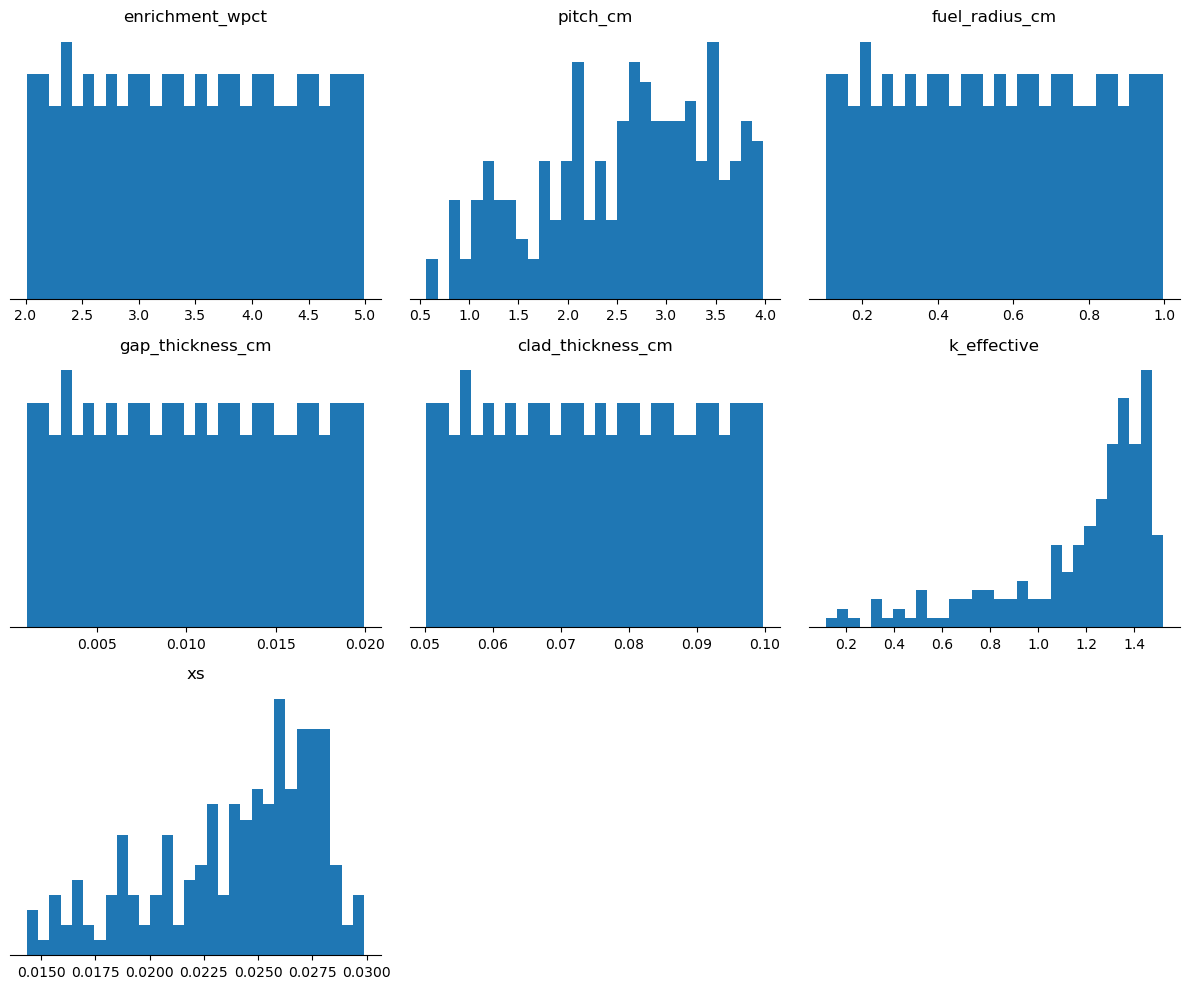

In [2]:
df = pd.read_csv('data/metadata.csv')
df.columns = df.columns.str.strip()

data = df.select_dtypes(include=['number']).columns
data_filtered = [col for col in data if col != 'pincell_id']

axes = df[data_filtered].hist(figsize=(12, 10), bins=30)

for ax in axes.flatten():
    ax.grid(False)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

## Training (model fitting)

Features
- Fuel enrichment
- Pin pitch $p$
- Fuel rod radius $r_f$
- Gap thickness $r_g$
- Cladding thickness $r_c$

Target
- Homogenised cross-section $\Sigma_{homog}$ (default)
- Effective multiplication factor $k_{eff}$

The default target variable is the homogenised cross-section $\Sigma_{homog}$, though users can readily substitute the effective multiplication factor $k_{eff}$.

The dataset is split into training and test sets using an 80/20 ratio, with a fixed random seed for reproducibility.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
features = ['enrichment_wpct', 'pitch_cm', 'fuel_radius_cm', 'gap_thickness_cm', 'clad_thickness_cm']
target = 'xs'

X = df[features]
y = df[target]

print(f'Dataset contains {len(X)} samples')

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dataset contains 200 samples


Instantiate and train a regression model. The default model is a [gradient boosting regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html), though users can substitute a [linear regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) or [random forest regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) model by uncommenting the relevant line. The hyperparameters can be adjusted as required.

In [5]:
# model = LinearRegression()
# model = RandomForestRegressor(n_estimators=100, random_state=42)
model = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42
)
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

## Testing

Evaluate the trained model on the held-out test set. We report the mean squared error (MSE) and the coefficient of determination ($R^2$) as summary metrics, and plot the observed against predicted values for $\Sigma_{homog}$. Points lying close to the dashed $x = y$ line indicate good predictive accuracy.

In [6]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.10f}")
print(f"R^2 Score: {r2:.5f}")

Mean Squared Error: 0.0000022887
R^2 Score: 0.79570


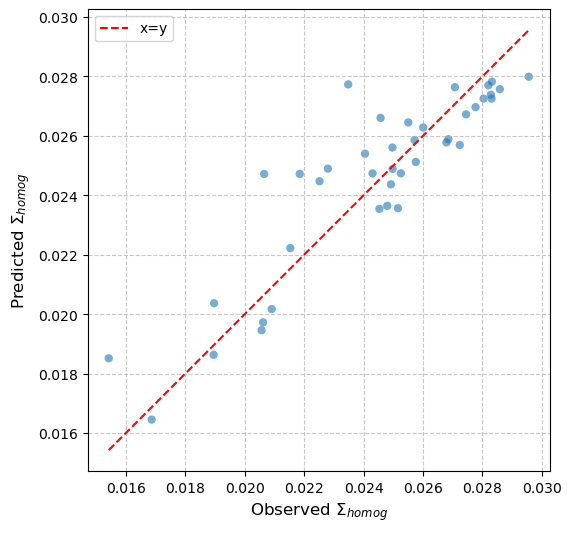

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='none')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='x=y')

plt.xlabel(r'Observed $\Sigma_{homog}$', fontsize=12)
plt.ylabel(r'Predicted $\Sigma_{homog}$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().set_aspect('equal', adjustable='box')
plt.savefig("observed-vs-predicted-tabular.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Importance

For tree-based models, we extract and display the feature importances to identify which design parameters have the greatest influence on the predicted $\Sigma_{homog}$. This step is skipped for linear regression, which does not expose feature importances in the same manner.

In [8]:
if isinstance(model, (RandomForestRegressor, GradientBoostingRegressor)):
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    print("\nFeature Importance:")
    print(importances)


Feature Importance:
fuel_radius_cm       0.518763
pitch_cm             0.386853
enrichment_wpct      0.060283
clad_thickness_cm    0.018728
gap_thickness_cm     0.015373
dtype: float64
